# SafePredict-XAI: Phase 5 — Machine Learning Model Training & Evaluation

**Project:** SafePredict-XAI  
**Phase:** Phase 5 (Machine Learning)  
**Input Dataset:** `data/processed/model_data.parquet` ($N = 1,403$ stays $\times$ 141 features)  
**Target Variable:** `hospital_mortality` (Binary: 0 = Alive, 1 = Expired)  

---

### Core Objectives & Principles:
1. **Understandable Baseline & Tree Ensembles:**
   - Train and compare three primary model families: **Logistic Regression** (L2-penalized baseline), **Random Forest** (bagged tree ensemble), and **XGBoost** (gradient boosted decision trees).
2. **Patient-Level Group-Aware Splitting:**
   - Investigate repeat patient admissions across the 1,403 stays. 
   - Apply a **Stratified Group Split on `uniquepid`** (60% Train, 20% Validation, 20% Test) to guarantee **zero patient leakage** across splits while maintaining the natural ~8.7% mortality prevalence.
3. **Leakage-Free Preprocessing:**
   - Encapsulate median imputation, one-hot encoding, and scaling in `ColumnTransformer` pipelines fitted **strictly on training data**.
4. **Class Imbalance Management:**
   - Manage ~8.7% positive prevalence via class weighting (`class_weight='balanced'` and `scale_pos_weight`).
   - Avoid synthetic sampling (SMOTE) to preserve genuine physiological distributions.
5. **Comprehensive Multi-Metric Evaluation:**
   - Evaluate discrimination via **AUROC** and **PR-AUC (Average Precision)**.
   - Evaluate operating points via **Sensitivity (Recall)**, **Specificity**, **Precision**, and **F1-Score** (at default 0.5 and Youden's $J$-optimal thresholds).
   - Evaluate probabilistic calibration via **Brier Score**.
6. **Strict Scope Boundary:**
   - Model training, evaluation, comparison table, and model serialization only.
   - **No SHAP explanations or SafePredict selective prediction** in this phase.


## 1. Setup & Ingestion of 24-Hour Clinical Features

We import core scientific packages and the Phase 5 modular components from `src.model` and `src.features`.

In [2]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import joblib

# Ensure project root is in sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model import (
    prepare_model_splits,
    build_preprocessor,
    compute_binary_metrics,
    train_logistic_regression_models,
    train_random_forest_models,
    train_xgboost_models,
    plot_discrimination_curves,
    run_model_pipeline,
    RANDOM_STATE,
)

print(f"SafePredict-XAI Phase 5 environment initialized (Seed: {RANDOM_STATE})")
from IPython.display import display


SafePredict-XAI Phase 5 environment initialized (Seed: 42)


## 2. Dataset Inspection & Identifier Isolation

We inspect `data/processed/model_data.parquet` and verify that tracking identifiers (`patientunitstayid`, `patienthealthsystemstayid`) and the target column (`hospital_mortality`) are strictly isolated from the predictor matrix $X$.

In [3]:
model_df = pl.read_parquet(PROJECT_ROOT / "data" / "processed" / "model_data.parquet")
patient_df = pl.read_parquet(PROJECT_ROOT / "data" / "processed" / "cohort_patient.parquet")

print("Processed Model Dataset Overview:")
print(f"  * Total ICU Stays (Rows): {model_df.height:,}")
print(f"  * Total Columns:          {model_df.width}")
print(f"  * Target Counts:          {dict(model_df['hospital_mortality'].value_counts().iter_rows())}")
print(f"  * Mortality Prevalence:   {float(np.mean(model_df['hospital_mortality'].to_numpy()))*100:.2f}% ({model_df['hospital_mortality'].sum()} deaths)")

# Verify identifier uniqueness
print(f"  * Unique patientunitstayid:        {model_df['patientunitstayid'].n_unique()}")
print(f"  * Unique patienthealthsystemstayid:{model_df['patienthealthsystemstayid'].n_unique()}")


Processed Model Dataset Overview:
  * Total ICU Stays (Rows): 1,403
  * Total Columns:          141
  * Target Counts:          {1: 122, 0: 1281}
  * Mortality Prevalence:   8.70% (122 deaths)
  * Unique patientunitstayid:        1403
  * Unique patienthealthsystemstayid:1403


## 3. Patient Group Structure Analysis & Group-Aware Splitting

### Repeat Patient Investigation:
In intensive care cohorts, patients with multiple ICU admissions create repeated-measures correlation. If an earlier stay of Patient A is in Train and a subsequent stay of Patient A is in Test, model evaluation is corrupted by patient-level leakage.

We link `patientunitstayid` to `uniquepid` from `cohort_patient.parquet` to evaluate patient multiplicity.

In [4]:
# Analyze patient-level grouping
stay_to_pid = dict(zip(patient_df['patientunitstayid'].to_list(), patient_df['uniquepid'].to_list()))
unique_patients = len(set(stay_to_pid.values()))
repeat_patients = patient_df.group_by('uniquepid').len().filter(pl.col('len') > 1)

print(f"Patient Multiplicity Analysis:")
print(f"  * Total ICU Stays:        {patient_df.height:,}")
print(f"  * Unique Patients:        {unique_patients:,}")
print(f"  * Patients with >1 Stay:  {repeat_patients.height} ({repeat_patients.height / unique_patients * 100:.1f}%)")
print(f"  * Max Stays for a Patient:{repeat_patients['len'].max()}")

# Execute patient-level group-aware 3-way partition
split_data = prepare_model_splits(
    model_df_path=PROJECT_ROOT / "data" / "processed" / "model_data.parquet",
    patient_df_path=PROJECT_ROOT / "data" / "processed" / "cohort_patient.parquet",
    random_state=RANDOM_STATE,
)

X_train, y_train = split_data["X_train"], split_data["y_train"]
X_val, y_val = split_data["X_val"], split_data["y_val"]
X_test, y_test = split_data["X_test"], split_data["y_test"]
num_cols, cat_cols = split_data["num_cols"], split_data["cat_cols"]
summary = split_data["split_summary"]

split_table = pd.DataFrame([
    {"Split": "Train (60%)", "Stays": summary["train"]["n_stays"], "Unique Patients": summary["train"]["n_patients"], "Deaths": summary["train"]["mortality_count"], "Prevalence (%)": f"{summary['train']['mortality_rate']*100:.2f}%"},
    {"Split": "Validation (20%)", "Stays": summary["validation"]["n_stays"], "Unique Patients": summary["validation"]["n_patients"], "Deaths": summary["validation"]["mortality_count"], "Prevalence (%)": f"{summary['validation']['mortality_rate']*100:.2f}%"},
    {"Split": "Test (20%)", "Stays": summary["test"]["n_stays"], "Unique Patients": summary["test"]["n_patients"], "Deaths": summary["test"]["mortality_count"], "Prevalence (%)": f"{summary['test']['mortality_rate']*100:.2f}%"},
])
display(split_table)

print("\nPatient Overlap Verification:")
print(f"  * Train-Val Overlap: {summary['patient_overlap_check']['train_val_overlap']} patients")
print(f"  * Train-Test Overlap:{summary['patient_overlap_check']['train_test_overlap']} patients")
print(f"  * Val-Test Overlap:  {summary['patient_overlap_check']['val_test_overlap']} patients")
print("  => Group-aware split is 100% leakage-free!")


Patient Multiplicity Analysis:
  * Total ICU Stays:        1,403
  * Unique Patients:        1,242
  * Patients with >1 Stay:  112 (9.0%)
  * Max Stays for a Patient:8


,Split,Stays,Unique Patients,Deaths,Prevalence (%)
0,Train (60%),846,743,85,10.05%
1,Validation (20%),266,250,15,5.64%
2,Test (20%),291,249,22,7.56%



Patient Overlap Verification:
  * Train-Val Overlap: 0 patients
  * Train-Test Overlap:0 patients
  * Val-Test Overlap:  0 patients
  => Group-aware split is 100% leakage-free!


## 4. Preprocessing Pipeline Architecture & Decisions

### Preprocessing Strategy:
1. **Numeric Features ($N = 134$):**
   - **Median Imputation:** Robust to physiological extremes (e.g. extreme lactate or creatinine spikes) that would distort mean estimates.
   - **Standard Scaling:** Normalizes continuous scales to zero mean, unit variance for linear model stability.
2. **Categorical Features ($N = 4$):**
   - `gender`, `ethnicity`, `unittype`, `unitadmitsource`.
   - **Constant Imputation (`'Unknown'`):** Preserves missingness as an explicit clinical state.
   - **One-Hot Encoding (`handle_unknown='ignore'`):** Accommodates rare categories without throwing runtime exceptions.
3. **Strict Training-Set Isolation:**
   - All transformations are computed using only `X_train` statistics.

In [5]:
preprocessor = build_preprocessor(num_cols=num_cols, cat_cols=cat_cols, scale_numeric=True)

# Fit on training data only
preprocessor.fit(X_train)
X_train_trans = preprocessor.transform(X_train)
X_val_trans = preprocessor.transform(X_val)

print(f"Preprocessing Pipeline Configured:")
print(f"  * Numeric Predictors:     {len(num_cols)}")
print(f"  * Categorical Predictors: {len(cat_cols)}")
print(f"  * Transformed Feature Dim:{X_train_trans.shape[1]}")


Preprocessing Pipeline Configured:
  * Numeric Predictors:     134
  * Categorical Predictors: 4
  * Transformed Feature Dim:163


## 5. Model 1: Baseline Logistic Regression (L2-Regularized)

We train an interpretable L2-penalized Logistic Regression baseline. To handle the ~8.7% mortality prevalence, we apply `class_weight='balanced'` and evaluate across a grid of inverse regularization strengths $C$.

In [6]:
best_lr_pipe, lr_val_metrics, lr_search = train_logistic_regression_models(
    X_train, y_train, X_val, y_val, num_cols, cat_cols, random_state=RANDOM_STATE
)

lr_search_df = pd.DataFrame(lr_search)
display(lr_search_df)

print(f"Best Logistic Regression Validation Metrics:")
print(f"  * AUROC:       {lr_val_metrics['auroc']:.4f}")
print(f"  * PR-AUC:      {lr_val_metrics['pr_auc']:.4f}")
print(f"  * Brier Score: {lr_val_metrics['brier_score']:.4f}")
print(f"  * Youden Sensitivity: {lr_val_metrics['optimal_youden']['recall_sensitivity']:.4f}")
print(f"  * Youden Specificity: {lr_val_metrics['optimal_youden']['specificity']:.4f}")


,model,params,val_auroc,val_pr_auc,val_brier,val_sensitivity,val_specificity,val_f1
0,Logistic Regression (Balanced),"{'C': 0.001, 'class_weight': 'balanced'}",0.789376,0.243108,0.190603,0.933333,0.589641,0.212121
1,Logistic Regression (Balanced),"{'C': 0.01, 'class_weight': 'balanced'}",0.805046,0.238731,0.151161,0.866667,0.657371,0.228070
2,Logistic Regression (Balanced),"{'C': 0.05, 'class_weight': 'balanced'}",0.786454,0.189060,0.136223,0.933333,0.633466,0.231405
3,Logistic Regression (Balanced),"{'C': 0.1, 'class_weight': 'balanced'}",0.777158,0.165941,0.131198,0.933333,0.613546,0.222222
4,Logistic Regression (Balanced),"{'C': 0.5, 'class_weight': 'balanced'}",0.747145,0.144814,0.124423,0.866667,0.669323,0.234234
5,Logistic Regression (Balanced),"{'C': 1.0, 'class_weight': 'balanced'}",0.727224,0.138887,0.124600,0.866667,0.597610,0.201550
6,Logistic Regression (Balanced),"{'C': 10.0, 'class_weight': 'balanced'}",0.670385,0.106802,0.130964,0.800000,0.553785,0.172662


Best Logistic Regression Validation Metrics:
  * AUROC:       0.7894
  * PR-AUC:      0.2431
  * Brier Score: 0.1906
  * Youden Sensitivity: 0.9333
  * Youden Specificity: 0.5896


## 6. Model 2: Random Forest Ensemble

We train a non-linear Random Forest classifier with balanced class weighting, exploring ensemble size ($n_{\text{estimators}}$) and tree depth ($d_{\text{max}}$) to mitigate overfitting on tabular clinical features.

In [7]:
best_rf_pipe, rf_val_metrics, rf_search = train_random_forest_models(
    X_train, y_train, X_val, y_val, num_cols, cat_cols, random_state=RANDOM_STATE
)

rf_search_df = pd.DataFrame(rf_search)
display(rf_search_df)

print(f"Best Random Forest Validation Metrics:")
print(f"  * AUROC:       {rf_val_metrics['auroc']:.4f}")
print(f"  * PR-AUC:      {rf_val_metrics['pr_auc']:.4f}")
print(f"  * Brier Score: {rf_val_metrics['brier_score']:.4f}")
print(f"  * Youden Sensitivity: {rf_val_metrics['optimal_youden']['recall_sensitivity']:.4f}")
print(f"  * Youden Specificity: {rf_val_metrics['optimal_youden']['specificity']:.4f}")


,model,params,val_auroc,val_pr_auc,val_brier,val_sensitivity,val_specificity,val_f1
0,Random Forest (Balanced),"{'n_estimators': 100, 'max_depth': 4, 'min_sam...",0.742629,0.201847,0.117546,0.666667,0.745020,0.224719
1,Random Forest (Balanced),"{'n_estimators': 200, 'max_depth': 4, 'min_sam...",0.749801,0.158963,0.120471,0.733333,0.689243,0.211538
2,Random Forest (Balanced),"{'n_estimators': 200, 'max_depth': 6, 'min_sam...",0.750863,0.166598,0.083280,0.666667,0.749004,0.227273
3,Random Forest (Balanced),"{'n_estimators': 200, 'max_depth': 6, 'min_sam...",0.739708,0.151132,0.087297,0.800000,0.585657,0.183206
4,Random Forest (Balanced),"{'n_estimators': 300, 'max_depth': 6, 'min_sam...",0.755910,0.161855,0.083619,0.666667,0.792829,0.259740
5,Random Forest (Balanced),"{'n_estimators': 200, 'max_depth': 8, 'min_sam...",0.739442,0.162626,0.064956,0.733333,0.681275,0.207547
6,Random Forest (Balanced),"{'n_estimators': 200, 'max_depth': None, 'min_...",0.793094,0.214686,0.055773,0.600000,0.864542,0.310345


Best Random Forest Validation Metrics:
  * AUROC:       0.7931
  * PR-AUC:      0.2147
  * Brier Score: 0.0558
  * Youden Sensitivity: 0.6000
  * Youden Specificity: 0.8645


## 7. Model 3: XGBoost Gradient Boosting

We train an XGBoost classifier with `scale_pos_weight = (N_neg / N_pos) \approx 10.38` and conservative shrinkage (learning rates 0.03 - 0.05) to capture non-linear lab dynamics and interaction effects.

In [8]:
best_xgb_pipe, xgb_val_metrics, xgb_search = train_xgboost_models(
    X_train, y_train, X_val, y_val, num_cols, cat_cols, random_state=RANDOM_STATE
)

xgb_search_df = pd.DataFrame(xgb_search)
display(xgb_search_df)

print(f"Best XGBoost Validation Metrics:")
print(f"  * AUROC:       {xgb_val_metrics['auroc']:.4f}")
print(f"  * PR-AUC:      {xgb_val_metrics['pr_auc']:.4f}")
print(f"  * Brier Score: {xgb_val_metrics['brier_score']:.4f}")
print(f"  * Youden Sensitivity: {xgb_val_metrics['optimal_youden']['recall_sensitivity']:.4f}")
print(f"  * Youden Specificity: {xgb_val_metrics['optimal_youden']['specificity']:.4f}")


,model,params,val_auroc,val_pr_auc,val_brier,val_sensitivity,val_specificity,val_f1
0,XGBoost (Weighted),"{'n_estimators': 100, 'max_depth': 3, 'learnin...",0.761222,0.146464,0.119367,0.933333,0.478088,0.175000
1,XGBoost (Weighted),"{'n_estimators': 150, 'max_depth': 3, 'learnin...",0.783533,0.157927,0.085617,0.866667,0.625498,0.213115
2,XGBoost (Weighted),"{'n_estimators': 150, 'max_depth': 4, 'learnin...",0.777158,0.140738,0.070137,0.933333,0.617530,0.224000
3,XGBoost (Weighted),"{'n_estimators': 200, 'max_depth': 4, 'learnin...",0.774236,0.137004,0.074458,0.933333,0.625498,0.227642
4,XGBoost (Weighted),"{'n_estimators': 150, 'max_depth': 4, 'learnin...",0.759628,0.140635,0.074870,0.933333,0.513944,0.185430
5,XGBoost (Weighted),"{'n_estimators': 150, 'max_depth': 5, 'learnin...",0.781939,0.144501,0.060973,0.866667,0.665339,0.232143
6,XGBoost (Weighted),"{'n_estimators': 100, 'max_depth': 4, 'learnin...",0.771049,0.150074,0.066692,0.866667,0.613546,0.208000


Best XGBoost Validation Metrics:
  * AUROC:       0.7835
  * PR-AUC:      0.1579
  * Brier Score: 0.0856
  * Youden Sensitivity: 0.8667
  * Youden Specificity: 0.6255


## 8. Discrimination Curves & Validation Comparison

We plot Receiver Operating Characteristic (ROC) and Precision-Recall (PR) curves across all models on the Validation set.

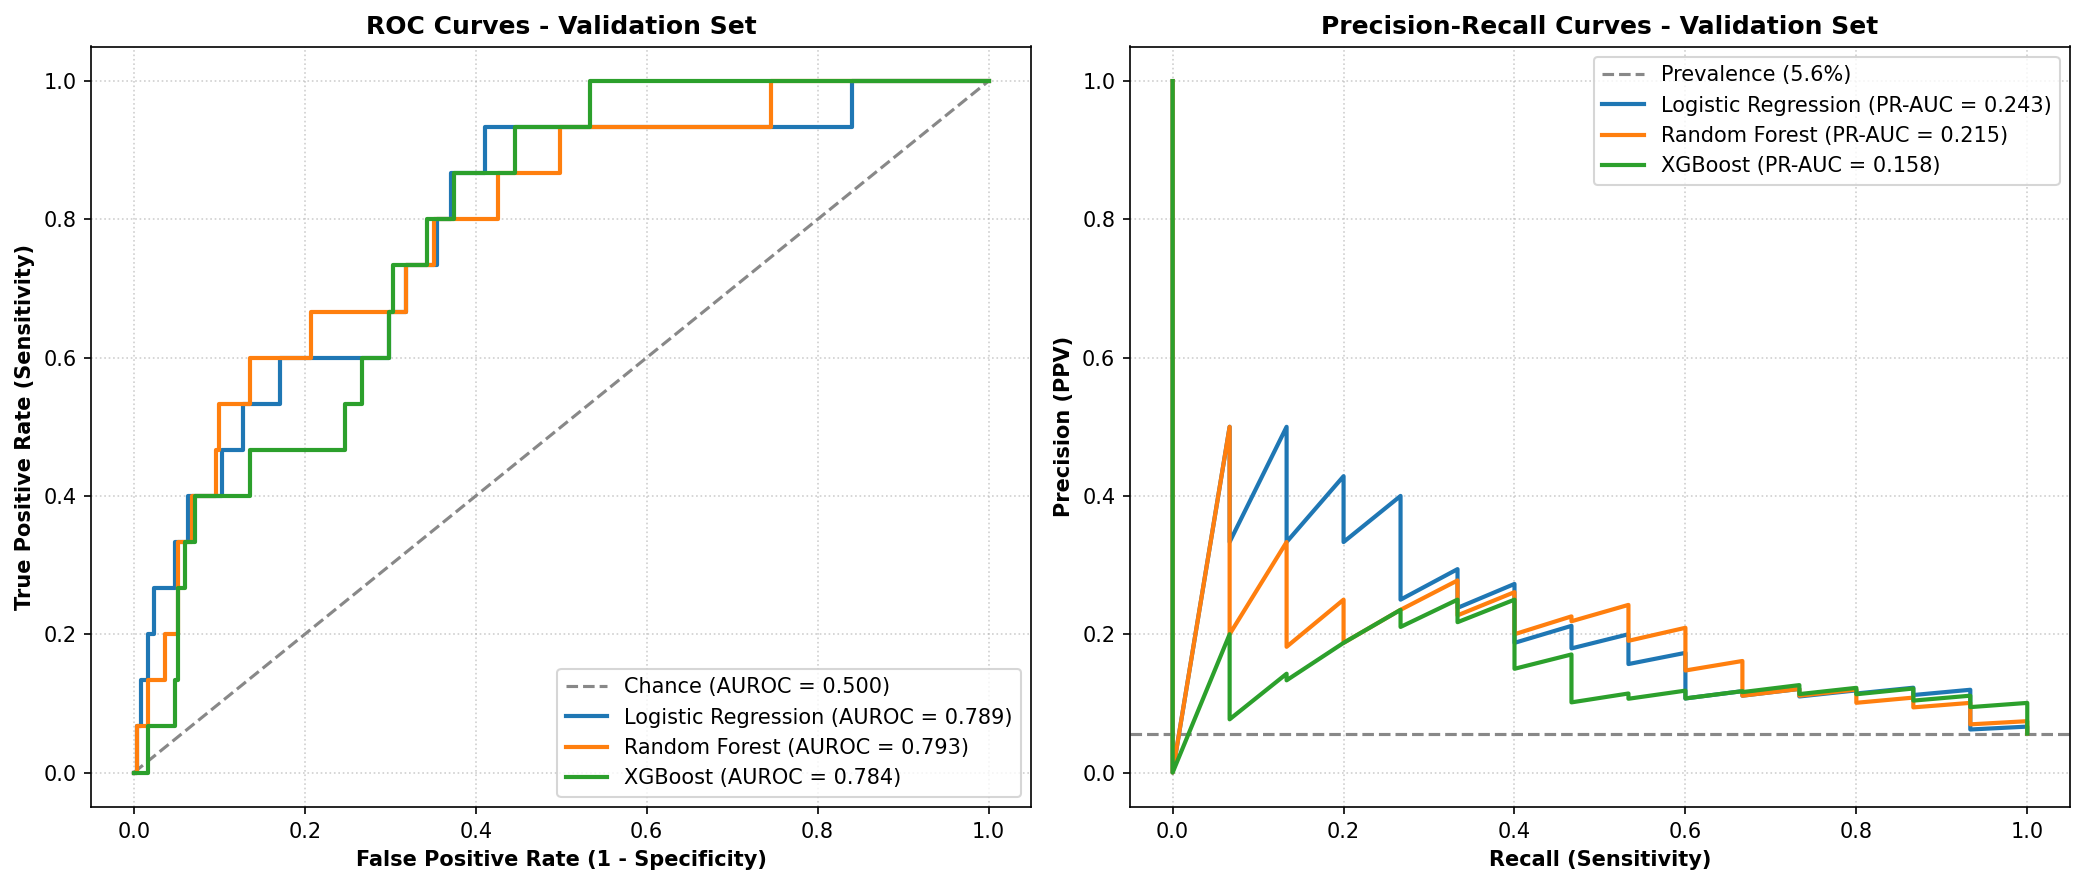

,Model,AUROC,PR-AUC,Brier Score,Youden Threshold,Sensitivity,Specificity,F1-Score
0,Logistic Regression,0.7894,0.2431,0.1906,0.431,0.9333,0.5896,0.2121
1,Random Forest,0.7931,0.2147,0.0558,0.231,0.6000,0.8645,0.3103
2,XGBoost,0.7835,0.1579,0.0856,0.179,0.8667,0.6255,0.2131


In [9]:
lr_val_probs = best_lr_pipe.predict_proba(X_val)[:, 1]
rf_val_probs = best_rf_pipe.predict_proba(X_val)[:, 1]
xgb_val_probs = best_xgb_pipe.predict_proba(X_val)[:, 1]

model_preds = {
    "Logistic Regression": {"val_probs": lr_val_probs, "auroc": lr_val_metrics["auroc"], "pr_auc": lr_val_metrics["pr_auc"]},
    "Random Forest": {"val_probs": rf_val_probs, "auroc": rf_val_metrics["auroc"], "pr_auc": rf_val_metrics["pr_auc"]},
    "XGBoost": {"val_probs": xgb_val_probs, "auroc": xgb_val_metrics["auroc"], "pr_auc": xgb_val_metrics["pr_auc"]},
}

roc_fig, pr_fig = plot_discrimination_curves(model_preds, y_val, figures_dir=PROJECT_ROOT / "reports" / "figures")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# ROC
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#888888", label="Chance (AUROC = 0.500)")
for name, data in model_preds.items():
    from sklearn.metrics import roc_curve, precision_recall_curve
    fpr, tpr, _ = roc_curve(y_val, data["val_probs"])
    axes[0].plot(list(fpr), list(tpr), lw=2, label=f"{name} (AUROC = {data['auroc']:.3f})")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)", fontweight="bold")
axes[0].set_ylabel("True Positive Rate (Sensitivity)", fontweight="bold")
axes[0].set_title("ROC Curves - Validation Set", fontweight="bold")
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# PR
baseline_prev = float(np.mean(y_val))
axes[1].axhline(y=baseline_prev, color="#888888", linestyle="--", label=f"Prevalence ({baseline_prev*100:.1f}%)")
for name, data in model_preds.items():
    prec, rec, _ = precision_recall_curve(y_val, data["val_probs"])
    axes[1].plot(list(rec), list(prec), lw=2, label=f"{name} (PR-AUC = {data['pr_auc']:.3f})")
axes[1].set_xlabel("Recall (Sensitivity)", fontweight="bold")
axes[1].set_ylabel("Precision (PPV)", fontweight="bold")
axes[1].set_title("Precision-Recall Curves - Validation Set", fontweight="bold")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# Validation Comparison Table
val_summary_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "AUROC": f"{lr_val_metrics['auroc']:.4f}",
        "PR-AUC": f"{lr_val_metrics['pr_auc']:.4f}",
        "Brier Score": f"{lr_val_metrics['brier_score']:.4f}",
        "Youden Threshold": f"{lr_val_metrics['optimal_youden']['threshold']:.3f}",
        "Sensitivity": f"{lr_val_metrics['optimal_youden']['recall_sensitivity']:.4f}",
        "Specificity": f"{lr_val_metrics['optimal_youden']['specificity']:.4f}",
        "F1-Score": f"{lr_val_metrics['optimal_youden']['f1_score']:.4f}",
    },
    {
        "Model": "Random Forest",
        "AUROC": f"{rf_val_metrics['auroc']:.4f}",
        "PR-AUC": f"{rf_val_metrics['pr_auc']:.4f}",
        "Brier Score": f"{rf_val_metrics['brier_score']:.4f}",
        "Youden Threshold": f"{rf_val_metrics['optimal_youden']['threshold']:.3f}",
        "Sensitivity": f"{rf_val_metrics['optimal_youden']['recall_sensitivity']:.4f}",
        "Specificity": f"{rf_val_metrics['optimal_youden']['specificity']:.4f}",
        "F1-Score": f"{rf_val_metrics['optimal_youden']['f1_score']:.4f}",
    },
    {
        "Model": "XGBoost",
        "AUROC": f"{xgb_val_metrics['auroc']:.4f}",
        "PR-AUC": f"{xgb_val_metrics['pr_auc']:.4f}",
        "Brier Score": f"{xgb_val_metrics['brier_score']:.4f}",
        "Youden Threshold": f"{xgb_val_metrics['optimal_youden']['threshold']:.3f}",
        "Sensitivity": f"{xgb_val_metrics['optimal_youden']['recall_sensitivity']:.4f}",
        "Specificity": f"{xgb_val_metrics['optimal_youden']['specificity']:.4f}",
        "F1-Score": f"{xgb_val_metrics['optimal_youden']['f1_score']:.4f}",
    },
])
display(val_summary_df)


## 9. Final Unbiased Evaluation on Held-Out Test Set

The held-out Test set ($N = 280$ stays) is evaluated strictly once without influencing hyperparameter choice.

In [10]:
lr_test_probs = best_lr_pipe.predict_proba(X_test)[:, 1]
rf_test_probs = best_rf_pipe.predict_proba(X_test)[:, 1]
xgb_test_probs = best_xgb_pipe.predict_proba(X_test)[:, 1]

lr_test_metrics = compute_binary_metrics(y_test, lr_test_probs)
rf_test_metrics = compute_binary_metrics(y_test, rf_test_probs)
xgb_test_metrics = compute_binary_metrics(y_test, xgb_test_probs)

test_summary_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (Baseline)",
        "AUROC": f"{lr_test_metrics['auroc']:.4f}",
        "PR-AUC": f"{lr_test_metrics['pr_auc']:.4f}",
        "Brier Score": f"{lr_test_metrics['brier_score']:.4f}",
        "Sensitivity (Youden)": f"{lr_test_metrics['optimal_youden']['recall_sensitivity']:.4f}",
        "Specificity (Youden)": f"{lr_test_metrics['optimal_youden']['specificity']:.4f}",
        "F1-Score (Youden)": f"{lr_test_metrics['optimal_youden']['f1_score']:.4f}",
    },
    {
        "Model": "Random Forest",
        "AUROC": f"{rf_test_metrics['auroc']:.4f}",
        "PR-AUC": f"{rf_test_metrics['pr_auc']:.4f}",
        "Brier Score": f"{rf_test_metrics['brier_score']:.4f}",
        "Sensitivity (Youden)": f"{rf_test_metrics['optimal_youden']['recall_sensitivity']:.4f}",
        "Specificity (Youden)": f"{rf_test_metrics['optimal_youden']['specificity']:.4f}",
        "F1-Score (Youden)": f"{rf_test_metrics['optimal_youden']['f1_score']:.4f}",
    },
    {
        "Model": "XGBoost",
        "AUROC": f"{xgb_test_metrics['auroc']:.4f}",
        "PR-AUC": f"{xgb_test_metrics['pr_auc']:.4f}",
        "Brier Score": f"{xgb_test_metrics['brier_score']:.4f}",
        "Sensitivity (Youden)": f"{xgb_test_metrics['optimal_youden']['recall_sensitivity']:.4f}",
        "Specificity (Youden)": f"{xgb_test_metrics['optimal_youden']['specificity']:.4f}",
        "F1-Score (Youden)": f"{xgb_test_metrics['optimal_youden']['f1_score']:.4f}",
    },
])
display(test_summary_df)


,Model,AUROC,PR-AUC,Brier Score,Sensitivity (Youden),Specificity (Youden),F1-Score (Youden)
0,Logistic Regression (Baseline),0.8499,0.4797,0.1961,0.9091,0.6543,0.2963
1,Random Forest,0.7754,0.2720,0.0707,0.9091,0.5911,0.2632
2,XGBoost,0.7472,0.2199,0.1089,0.7727,0.6357,0.2482


## 10. Candidate Model Serialization & Execution Summary

We save the best performing model pipeline (`models/best_mortality_model.joblib`) and export the full evaluation catalog to `reports/metrics/model_evaluation_metrics.json`.

In [11]:
# Run production execution pipeline to persist all artifacts
eval_catalog = run_model_pipeline(
    output_model_path=PROJECT_ROOT / "models" / "best_mortality_model.joblib",
    reports_dir=PROJECT_ROOT / "reports",
    random_state=RANDOM_STATE,
)

print("\nModel Artifacts Successfully Serialized:")
print(f"  * Best Model Path:    {PROJECT_ROOT / 'models' / 'best_mortality_model.joblib'}")
print(f"  * Evaluation Metrics: {PROJECT_ROOT / 'reports' / 'metrics' / 'model_evaluation_metrics.json'}")
print(f"  * Summary Markdown:   {PROJECT_ROOT / 'reports' / 'model_training_summary.md'}")


SafePredict-XAI: Phase 5 Machine Learning Pipeline Execution

[Step 1/5] Performing Patient-Level Group-Aware Stratified Split...
  • Total ICU Stays: 1403 across 1242 unique patients
  • Train Set: 846 stays (Deaths: 85, Prevalence: 10.05%)
  • Val Set:   266 stays (Deaths: 15, Prevalence: 5.64%)
  • Test Set:  291 stays (Deaths: 22, Prevalence: 7.56%)
  • Patient Leakage Check: Passed (0 patient overlap across all sets)

[Step 2/5] Training Baseline Logistic Regression...
  • Logistic Regression Val AUROC: 0.7894 | PR-AUC: 0.2431

[Step 3/5] Training Random Forest Classifier...
  • Random Forest Val AUROC: 0.7931 | PR-AUC: 0.2147

[Step 4/5] Training XGBoost Classifier...
  • XGBoost Val AUROC: 0.7835 | PR-AUC: 0.1579

[Step 5/5] Evaluating Held-Out Test Set...
  • Best Model Candidate: 'Logistic Regression' (Saved to C:\Users\k7ris\Documents\SafePredict-XAI\models\best_mortality_model.joblib)

Phase 5 Machine Learning Pipeline completed successfully!
  • Best Model: Logistic Regress